# Sistema de Recomendación de Películas Basado en Contenido

**NLP — UNSAM 1c2026**

La idea es sencilla de contar: tenemos un catálogo de ~4.970 películas (con sinopsis,
keywords, género, año y director) y 14 usuarios. De cada usuario sabemos dos cosas:
qué películas vio (su *historial*) y qué quiere ver ahora, dicho en palabras (su *query*).
El objetivo es, para cada uno, devolver 5 películas que le puedan gustar, usando **solo
el contenido** de las películas (nada de "a quién más le gustó esto", porque no tenemos
datos de otros usuarios reales).

Probamos **dos formas distintas de representar una película** y las comparamos sobre los
mismos 14 perfiles:

- **Estrategia A — TF-IDF (léxica):** cuenta qué palabras aparecen y las pondera. Buena
  para coincidencias de vocabulario exacto.
- **Estrategia B — Sentence Embeddings (semántica):** representa el *significado* del texto
  en un vector denso. Maneja sinónimos, lenguaje natural y la mezcla español/inglés.

Las dos se construyen **sobre el mismo texto** (descripción + keywords + género concatenados),
así la única diferencia entre A y B es *cómo* se representa ese texto, no *qué* texto se usa.

El recorrido del notebook: (0) configuración, (1) los datos, (2) conectar historial con
catálogo, (3) preprocesamiento, (4) las dos representaciones, (5) modelar al usuario,
(6) ranking, (7) evaluación, (8) conclusiones.

## 0. Configuración y reproducibilidad

Fijamos una semilla única para que todo lo que tenga azar (sobre todo el baseline aleatorio)
dé igual en cada corrida. También definimos las rutas y dos constantes que vamos a justificar
más adelante: el umbral de *fuzzy matching* (0.80, ver §2) y el modelo de embeddings, pinneado
a un SHA fijo de HuggingFace para que los vectores sean siempre los mismos.

In [1]:
import os
import random
import warnings

import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = "data"
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

PLOTS_PATH    = os.path.join(DATA_DIR, "plots.csv")
PROFILES_PATH = os.path.join(DATA_DIR, "user_profiles.csv")

# Umbral de fuzzy matching: justificado en §2 (compromiso entre precisión y recall de títulos).
FUZZY_THRESHOLD = 0.80

# Modelo de embeddings (Estrategia B), pinneado a un SHA fijo del Hub: si HuggingFace actualiza
# el modelo upstream, seguimos usando exactamente esta versión. El SHA va embebido en el nombre
# del .npy cacheado; para regenerar con otra versión, cambiar el SHA y borrar artifacts/embeddings_*.
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
MODEL_SHA  = "4328cf26390c98c5e3c738b4460a05b95f4911f5"

print("Semilla fija:", SEED)
print("Threshold fuzzy:", FUZZY_THRESHOLD)
print("Modelo embeddings:", MODEL_NAME, "| SHA:", MODEL_SHA[:8])

Semilla fija: 42
Threshold fuzzy: 0.8
Modelo embeddings: sentence-transformers/paraphrase-multilingual-mpnet-base-v2 | SHA: 4328cf26


In [2]:
# Versiones del entorno (para reproducibilidad). Si algo falta, el notebook avisa en vez de
# fallar más adelante con un error críptico.
import importlib

for pkg in ["numpy", "pandas", "sklearn", "sentence_transformers", "spacy", "nltk", "rapidfuzz"]:
    try:
        mod = importlib.import_module(pkg)
        print(f"  {pkg}: {getattr(mod, '__version__', '?')}")
    except ImportError:
        print(f"  {pkg}: NO INSTALADO")

import spacy
try:
    nlp_model = spacy.load("es_core_news_sm")
    print(f"  spaCy es_core_news_sm: {nlp_model.meta['version']}")
except OSError:
    nlp_model = None
    print("  ADVERTENCIA: es_core_news_sm no encontrado. Ejecutar: python -m spacy download es_core_news_sm")

  numpy: 2.4.5
  pandas: 3.0.3


  sklearn: 1.8.0


/home/gerar/facultad/nlp-content-based-recommender/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  sentence_transformers: 5.5.0


  spacy: 3.8.14
  nltk: 3.9.4
  rapidfuzz: 3.14.5


  spaCy es_core_news_sm: 3.8.0


## 1. Los datos: qué tenemos para recomendar

Antes de modelar nada conviene mirar la materia prima. Cada película trae:

- **description**: la sinopsis en español. Es la señal más rica, pero también la más despareja.
- **keywords**: etiquetas separadas por comas, en una mezcla de español e inglés.
- **genre**: el género, también separado por comas y con idioma mixto.
- **year**, **name**, **director**: metadata. Usamos `name` para conectar el historial.

**¿Usamos todos los campos?** No. Para representar el *contenido* nos quedamos con
`description + keywords + genre`. Dejamos afuera `year` (el año no dice mucho del gusto y tiene
nulos) y `director` (señal potencialmente fuerte, pero con ~500 nulos —ver abajo— y nombres
propios que ni TF-IDF ni los embeddings de sinopsis aprovechan bien). Es una simplificación
consciente: incorporar `director` sería una mejora natural a futuro.

Mirando los datos aparecen **tres limitaciones estructurales** que condicionan todo lo demás.
No las afirmamos de memoria: las mostramos con ejemplos concretos abajo.

In [3]:
import pandas as pd

plots    = pd.read_csv(PLOTS_PATH)
profiles = pd.read_csv(PROFILES_PATH)

print("plots.csv    →", len(plots), "filas |", list(plots.columns))
print("profiles.csv →", len(profiles), "filas |", list(profiles.columns))
print("\nNulos por columna en plots.csv:")
print(plots.isnull().sum().to_string())

plots.csv    → 4967 filas | ['description', 'keywords', 'genre', 'year', 'name', 'director']
profiles.csv → 14 filas | ['id', 'nombre', 'tipo_perfil', 'pelicula_1', 'pelicula_2', 'pelicula_3', 'pelicula_4', 'pelicula_5', 'query']

Nulos por columna en plots.csv:
description      0
keywords         0
genre            0
year            34
name             0
director       500


**Limitación 1 — Sinopsis de longitud muy dispar.** Las sinopsis van de muy cortas a muy
largas. En principio una sinopsis demasiado corta no daría para representar bien una película,
así que dejamos preparada una marca `low_confidence` (sinopsis < 20 chars) para evitar
recomendar ruido. **Aclaración honesta:** al mirar *este* corpus, la sinopsis más corta tiene
~33 caracteres y **ninguna** baja de 20 (lo verificamos abajo), así que esa salvaguarda no
llega a activarse acá. La dispersión de longitudes igual existe y conviene tenerla a la vista.

In [4]:
# Buscamos sinopsis vacías o muy cortas (<20 caracteres) para ver si existen en este corpus.
desc = plots["description"].fillna("")
cortas = plots[desc.str.len() < 20]
print(f"Películas con sinopsis < 20 chars: {len(cortas)} ({(desc.str.len() < 20).mean():.1%})")
print(f"Sinopsis más corta del catálogo: {int(desc.str.len().min())} caracteres.")
# Mostramos las 4 más cortas (aunque ninguna sea realmente "vacía"):
mas_cortas = plots.loc[desc.str.len().sort_values().index[:4], ["name", "description"]]
for _, r in mas_cortas.iterrows():
    print(f"  - {r['name']}: \"{str(r['description'])[:60]}\" ({len(str(r['description']))} chars)")

Películas con sinopsis < 20 chars: 0 (0.0%)
Sinopsis más corta del catálogo: 33 caracteres.
  - Belly: "Dos mafiosos tienen una epifanía." (33 chars)
  - Copying Beethoven: "El último año de vida de Beethoven." (35 chars)
  - El otro lado de la cama: "Dos parejas se unen en su búsqueda de amor." (43 chars)
  - Man on the Moon: "La vida del cómico legendario Andy Kaufman." (43 chars)


**Limitación 2 — Idioma mixto.** `keywords` y `genre` mezclan español e inglés. Esto le pega
distinto a cada estrategia: TF-IDF (A) lematiza en español, así que los tokens ingleses quedan
medio sueltos; los embeddings (B), al ser multilingües, los entienden de forma nativa. Es uno
de los motivos por los que esperamos que B se banque mejor el ruido.

In [5]:
# Ejemplos reales de keywords/genre con español e inglés en la misma fila.
muestra = plots[plots["keywords"].fillna("").str.contains(",")].head(3)
for _, r in muestra.iterrows():
    print(f"- {r['name']}")
    print(f"    genre:    {r['genre']}")
    print(f"    keywords: {str(r['keywords'])[:90]}")

- Herida abierta
    genre:    acción, crimen, suspense
    keywords: vietnam war veteran, heroína, drogas, narcotraficante, corrupt cop
- Elvira, reina de las tinieblas
    genre:    comedia, terror
    keywords: herencia, hostess, comedia negra, pueblo, magia
- Durmiendo con su enemigo
    genre:    drama, suspense
    keywords: violencia doméstica, muerte fingida, borderline personality disorder, relación madre hija,


**Limitación 3 — Perfiles desbalanceados.** Los 14 usuarios están etiquetados como `definido`
(gustos claros y coherentes) o `ambiguo` (historial disperso, query vaga). No están al 50/50.
Si solo miramos una métrica global, vamos a estar mirando sobre todo a los `definido`; por eso
después segmentamos por tipo.

In [6]:
print("Distribución de tipo_perfil:")
print(profiles["tipo_perfil"].value_counts().to_string())

# Estos nombres se usan luego en la segmentación y el desempate de la evaluación.
TIPOS_DISPERSOS = ["ambiguo"]
TIPOS_DEFINIDOS = ["definido"]

Distribución de tipo_perfil:
tipo_perfil
definido    10
ambiguo      4


Sinopsis (chars) — mín: 33  mediana: 152  media: 154  máx: 258


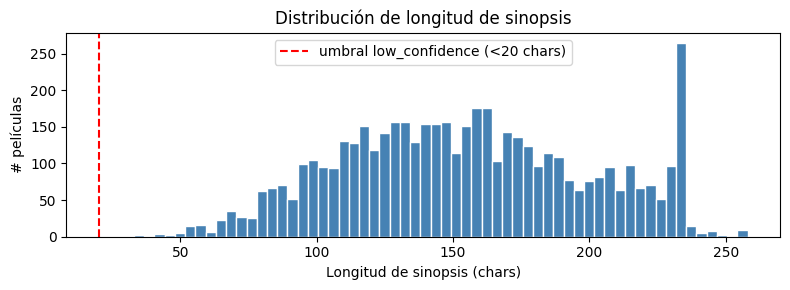

In [7]:
# Histograma de longitudes de sinopsis: confirma visualmente la limitación 1.
import matplotlib.pyplot as plt

desc_len = plots["description"].fillna("").str.len()
print(f"Sinopsis (chars) — mín: {desc_len.min()}  mediana: {desc_len.median():.0f}  "
      f"media: {desc_len.mean():.0f}  máx: {desc_len.max()}")

plt.figure(figsize=(8, 3))
plt.hist(desc_len[desc_len > 0], bins=60, color="steelblue", edgecolor="white")
plt.axvline(20, color="red", linestyle="--", label="umbral low_confidence (<20 chars)")
plt.xlabel("Longitud de sinopsis (chars)")
plt.ylabel("# películas")
plt.title("Distribución de longitud de sinopsis")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "eda_synopsis_len.png"), dpi=150)
plt.show()

## 2. Conectar el historial con el catálogo (fuzzy matching)

Acá hay un problema concreto: el historial de cada usuario son títulos escritos a mano
("Matrix", "Amélie", …), pero para usarlos necesitamos encontrar esa misma película en la
columna `name` del catálogo. Y los títulos **no coinciden carácter por carácter**: cambia una
tilde, falta un subtítulo, hay variantes ("Amélie" vs "Amelie"), etc.

¿Por qué *fuzzy* y no otra cosa?

- **Match exacto:** perderíamos todas esas variantes ortográficas. Demasiado estricto.
- **Embeddings de títulos:** sobredimensionado. Los títulos son cadenas cortas; medir
  parecido de *strings* alcanza y sobra, no hace falta semántica para esto.
- **Fuzzy (similitud de strings):** el punto justo. Toleramos diferencias chicas de escritura
  pero seguimos comparando texto, no significado.

Usamos `token_sort_ratio` de rapidfuzz (normaliza orden de palabras) y nos quedamos con el
mejor candidato si su score supera un umbral.

In [8]:
from rapidfuzz import fuzz, process as rfprocess

corpus_names = plots["name"].fillna("").tolist()

def best_match(title: str, choices: list[str]) -> tuple[str, float]:
    """Devuelve (mejor_título_del_catálogo, score en [0,1]) para un título dado."""
    result = rfprocess.extractOne(title, choices, scorer=fuzz.token_sort_ratio)
    if result is None:
        return ("", 0.0)
    match, score, _ = result
    return (match, score / 100.0)  # rapidfuzz devuelve 0–100; pasamos a 0–1

**¿Qué umbral elegir?** Algunos ejemplos reales calculados sobre nuestro propio historial:

In [9]:
# Tomamos algunos títulos del historial y miramos su mejor match en el catálogo.
ejemplos = ["Matrix", "Amélie", "El exorcista", "Paddington"]
print(f"{'título historial':<22} {'mejor match catálogo':<28} {'score':>6}")
print("-" * 58)
for t in ejemplos:
    m, s = best_match(t, corpus_names)
    print(f"{t:<22} {m:<28} {s:>6.2f}")

título historial       mejor match catálogo          score
----------------------------------------------------------
Matrix                 Matrix                         1.00
Amélie                 Amelie                         0.83
El exorcista           El exorcista III               0.86
Paddington             Carrington                     0.70


Lo que se ve (y el compromiso que hay que hacer):

- **"Matrix" → "Matrix"** (score 1.0): match perfecto, sin drama.
- **"Amélie" → "Amelie"** (~0.83): misma película, solo cambia la tilde. Un *verdadero* match
  que queremos conservar.
- **"El exorcista" → "El exorcista III"** (~0.86): acá fuzzy se equivoca. El catálogo no tiene
  "El exorcista" a secas, y el más parecido es **otra película** (una secuela). Es un falso
  positivo que contamina el perfil.
- **"Paddington" → algo no relacionado** (score bajo): correctamente descartado.

El problema es que **no hay un corte limpio**: el verdadero match "Amelie" (0.83) está *por
debajo* del falso positivo "El exorcista III" (0.86). Cualquier umbral que saque el falso
positivo (≥0.87) también nos hace perder "Amelie" y otros matches legítimos con variantes
ortográficas; bajar el umbral recupera "Amelie" pero deja entrar "El exorcista III".

Elegimos **0.80**, priorizando **recall de títulos** (conectar la mayor cantidad de historial
posible) y aceptando algún falso positivo aislado como "El exorcista III". El motivo práctico:
con 0.80 conservamos más historial efectivo y más perfiles evaluables (sobre todo los `ambiguo`,
que ya tienen pocos matches); y como veremos en §7, ser más estrictos no mejora las
recomendaciones —solo nos deja con menos datos para evaluar—. Lo dejamos anotado como un
límite conocido del matching por strings: fuzzy es barato y suficiente, pero no infalible.

In [10]:
# Cobertura: ¿cuántos títulos del historial logramos conectar con el catálogo a 0.90?
_hist_cols  = [f"pelicula_{i}" for i in range(1, 6)]
hist_titles = [t for t in profiles[_hist_cols].values.flatten()
               if pd.notna(t) and str(t).strip()]
scores = [best_match(str(t), corpus_names)[1] for t in set(hist_titles)]
n_ok = sum(s >= FUZZY_THRESHOLD for s in scores)
print(f"Títulos únicos del historial: {len(scores)}")
print(f"Conectados al catálogo (score ≥ {FUZZY_THRESHOLD}): {n_ok} ({n_ok/len(scores):.0%})")

Títulos únicos del historial: 64
Conectados al catálogo (score ≥ 0.8): 57 (89%)


## 3. Preprocesamiento

Cada estrategia necesita el texto preparado distinto:

- **Estrategia A (TF-IDF):** sí limpiamos y lematizamos. Pasamos a minúsculas, sacamos lo que
  no sea letra, tokenizamos con spaCy, filtramos stopwords y reducimos cada palabra a su lema
  (así "corría", "corriendo", "corre" cuentan como lo mismo). Para contar palabras, normalizar
  ayuda.
- **Estrategia B (Embeddings):** **NO** lematizamos ni limpiamos agresivo. El modelo fue
  entrenado sobre lenguaje natural completo; sacarle stopwords y mutilar las palabras le
  *degrada* el embedding. Le pasamos el texto casi crudo.

In [11]:
import re
import nltk

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords as nltk_sw

# Stopwords del español + algunas de dominio que aparecen en casi toda sinopsis y no discriminan.
STOPWORDS_ES = set(nltk_sw.words("spanish"))
DOMAIN_SW = {"película", "pelicula", "historia", "film", "filme",
             "hombre", "mujer", "año", "vida", "vez", "día", "mundo"}
STOPWORDS = STOPWORDS_ES | DOMAIN_SW

def _clean_text(text: str) -> str:
    """Minúsculas y se queda solo con letras españolas y espacios."""
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)  # fuera dígitos, puntuación, etc.
    text = re.sub(r"\s+", " ", text)              # colapsa espacios múltiples
    return text.strip()

def preprocess_for_tfidf(text: str, nlp) -> str:
    """Pipeline A: limpieza → lematización spaCy → filtro de stopwords y tokens cortos."""
    if not text or not isinstance(text, str):
        return ""
    doc = nlp(_clean_text(text), disable=["ner", "parser"])  # apagamos lo que no usamos (rapidez)
    tokens = [t.lemma_ for t in doc
              if t.lemma_ not in STOPWORDS and not t.is_space and len(t.lemma_) > 2]
    return " ".join(tokens)

def build_corpus_text(row: pd.Series) -> str:
    """Texto base de una película: description + keywords + genre. MISMO input para A y B."""
    parts = [str(row.get("description", "") or ""),
             str(row.get("keywords",    "") or ""),
             str(row.get("genre",       "") or "")]
    return " ".join(p for p in parts if p)

In [12]:
# Manejo de nulos y marca de baja confianza (limitación 1 del EDA).
MIN_DESC_LEN = 20
plots = plots.copy()
for col in ["description", "keywords", "genre"]:
    plots[col] = plots[col].fillna("")
plots["low_confidence"] = plots["description"].str.len() < MIN_DESC_LEN
print(f"Películas low_confidence (<{MIN_DESC_LEN} chars): "
      f"{plots['low_confidence'].sum()} ({plots['low_confidence'].mean():.1%})")

# Texto base compartido por ambas estrategias.
plots["text_raw"] = plots.apply(build_corpus_text, axis=1)

Películas low_confidence (<20 chars): 0 (0.0%)


In [13]:
# Lematización para A. Procesamos en batches con nlp.pipe (mucho más rápido que uno por uno).
if nlp_model is None:
    raise RuntimeError("spaCy es_core_news_sm no encontrado. "
                       "Ejecutar: python -m spacy download es_core_news_sm")

print("Preprocesando corpus para Estrategia A (puede tardar ~1 min)...")
processed_A = []
batch_size = 256
raw_texts = plots["text_raw"].tolist()
for i in range(0, len(raw_texts), batch_size):
    batch = [_clean_text(t) for t in raw_texts[i:i + batch_size]]
    for doc in nlp_model.pipe(batch, disable=["ner", "parser"]):
        tokens = [t.lemma_ for t in doc
                  if t.lemma_ not in STOPWORDS and not t.is_space and len(t.lemma_) > 2]
        processed_A.append(" ".join(tokens))

plots["text_proc_A"] = processed_A
print("Preprocesamiento A completado.")

Preprocesando corpus para Estrategia A (puede tardar ~1 min)...


Preprocesamiento A completado.


## 4. Dos formas de representar una película

Misma película, mismo texto de entrada, dos vectores distintos. Ambos quedan
**L2-normalizados** (norma = 1), lo que después nos deja calcular similitud coseno como un
simple producto punto.

### 4A — TF-IDF (representación léxica)

**Intuición:** cuenta qué palabras aparecen en la película y las pondera. Una palabra que sale
en *esta* película pero es rara en el resto del catálogo (p. ej. "samurái") pesa mucho; una que
sale en todas (ya filtramos esas como stopwords) pesa poco. El resultado es un vector enorme y
disperso (una dimensión por término del vocabulario). Es excelente para **coincidencias léxicas
exactas**: si dos pelis usan el mismo vocabulario específico, quedan cerca.

In [14]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

TFIDF_CACHE        = os.path.join(ARTIFACTS_DIR, "tfidf_vectorizer.pkl")
TFIDF_MATRIX_CACHE = os.path.join(ARTIFACTS_DIR, "tfidf_matrix.pkl")

if os.path.exists(TFIDF_CACHE) and os.path.exists(TFIDF_MATRIX_CACHE):
    print("Cargando TF-IDF desde cache...")
    with open(TFIDF_CACHE, "rb") as f:
        vectorizer_A = pickle.load(f)
    with open(TFIDF_MATRIX_CACHE, "rb") as f:
        M_A = pickle.load(f)
else:
    print("Ajustando TF-IDF...")
    vectorizer_A = TfidfVectorizer(
        min_df=2,            # ignora términos que aparecen en una sola película (ruido)
        max_df=0.85,         # ignora términos demasiado comunes
        ngram_range=(1, 2),  # unigramas y bigramas ("ciencia ficción" como una unidad)
        sublinear_tf=True, smooth_idf=True, norm="l2",  # norm="l2" → vectores normalizados
    )
    M_A = vectorizer_A.fit_transform(plots["text_proc_A"])
    with open(TFIDF_CACHE, "wb") as f:
        pickle.dump(vectorizer_A, f)
    with open(TFIDF_MATRIX_CACHE, "wb") as f:
        pickle.dump(M_A, f)
    print("TF-IDF guardado en cache.")

print(f"Matriz TF-IDF: {M_A.shape}  |  Vocabulario: {len(vectorizer_A.vocabulary_):,}")

Cargando TF-IDF desde cache...
Matriz TF-IDF: (4967, 17382)  |  Vocabulario: 17,382


In [15]:
# Chequeo de norma L2: cada fila no nula debería tener norma ≈ 1 (lo pedimos con norm="l2").
# Las filas nulas son películas sin texto útil (low_confidence sin sinopsis).
sumas_cuadrados = np.asarray((M_A.power(2)).sum(axis=1)).ravel()  # ||fila||^2
filas_no_nulas = sumas_cuadrados > 0
normas_A = np.sqrt(sumas_cuadrados[filas_no_nulas])
assert np.allclose(normas_A, 1.0, atol=1e-6), f"Normas A no son 1.0: min={normas_A.min():.6f}"
print(f"✓ Norma L2 OK: {filas_no_nulas.sum()} filas no nulas ≈ 1.0  |  "
      f"{(~filas_no_nulas).sum()} filas nulas (sin texto)")

✓ Norma L2 OK: 4967 filas no nulas ≈ 1.0  |  0 filas nulas (sin texto)


### 4B — Sentence Embeddings (representación semántica)

**Intuición:** en vez de contar palabras, un modelo pre-entrenado lee el texto y lo resume en
un vector denso de 768 dimensiones que captura el *significado*. Dos sinopsis que cuentan lo
mismo con palabras distintas quedan cerca igual (algo que TF-IDF no puede). Como el modelo es
**multilingüe**, también digiere bien la mezcla español/inglés de keywords y género.

Usamos `paraphrase-multilingual-mpnet-base-v2`, pinneado al SHA de §0.

In [16]:
from sentence_transformers import SentenceTransformer

EMB_CACHE = os.path.join(ARTIFACTS_DIR, f"embeddings_B_{MODEL_SHA[:8]}.npy")

print(f"Cargando modelo: {MODEL_NAME} (revision={MODEL_SHA[:8]})")
model_B = SentenceTransformer(MODEL_NAME, revision=MODEL_SHA)

def encode_texts(texts: list[str], model, cache_path: str) -> np.ndarray:
    """Codifica textos a embeddings normalizados; cachea en disco (SHA en el nombre)."""
    if os.path.exists(cache_path):
        print(f"  Cargando embeddings desde {cache_path}...")
        return np.load(cache_path)
    print(f"  Codificando {len(texts)} textos (puede tardar 2–5 min en CPU)...")
    E = model.encode(texts, batch_size=64, convert_to_numpy=True,
                     normalize_embeddings=True, show_progress_bar=True)
    np.save(cache_path, E)
    return E

# Mismo texto base que A (description + keywords + genre): la única diferencia es la representación.
E_B = encode_texts(plots["text_raw"].tolist(), model_B, EMB_CACHE)
print(f"Matriz de embeddings B: {E_B.shape}")

Cargando modelo: sentence-transformers/paraphrase-multilingual-mpnet-base-v2 (revision=4328cf26)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:  63%|██████▎   | 126/199 [00:00<00:00, 1256.84it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1617.74it/s]

  Cargando embeddings desde artifacts/embeddings_B_4328cf26.npy...
Matriz de embeddings B: (4967, 768)


In [17]:
# Chequeo de norma L2 (pedimos normalize_embeddings=True al codificar).
normas_B = np.linalg.norm(E_B, axis=1)
assert np.allclose(normas_B, 1.0, atol=1e-3), "Normas B no son 1.0"
print(f"✓ Norma L2 B OK: norma_media={normas_B.mean():.6f}")

✓ Norma L2 B OK: norma_media=1.000000


## 5. Modelar al usuario

Tenemos **dos señales** sobre cada usuario, y NO dicen lo mismo:

- **El historial** (qué vio): muestra su gusto *revelado*, lo que de hecho consume.
- **La query** (qué pide, en palabras): su intención *declarada* para ahora.

**¿Cómo resumimos el historial en un solo vector?** Promediamos los vectores de las películas
vistas → un **centroide**, el "punto medio" del gusto. ¿Por qué promediar y no concatenar?
Porque concatenar daría un vector de tamaño variable (depende de cuántas pelis matchearon) e
incomparable con el resto; el centroide vive en el mismo espacio que las películas, así que
podemos medir similitud directo contra el catálogo.

**¿Cómo combinamos historial y query?** Con una mezcla ponderada:
`v_user = α · v_hist + (1 − α) · v_query`, renormalizada. El `α` decide a quién creerle más.

**¿Y por qué α adaptativo?** Porque no todos los historiales son igual de confiables. Si las 5
películas vistas son re parecidas entre sí (historial *coherente*), el centroide es una señal
fuerte → subimos α, le creemos al historial. Si están por todos lados (historial *disperso*),
el centroide es un promedio sin sentido → bajamos α y le damos más peso a la query. Medimos esa
coherencia con la **dispersión del historial** (qué tan poco se parecen entre sí las pelis vistas).

**Casos de degradación elegante:**
- Si **ninguna** peli del historial matcheó el catálogo → no hay centroide, nos quedamos solo
  con la query (α = 0).
- Si además, en la Estrategia A, la query no tiene **ninguna** palabra del vocabulario (todo el
  vector da cero) → caemos al **centroide del corpus**, la "película promedio". No es genial,
  pero es una respuesta determinista y razonable en vez de un vector nulo. En la Estrategia B
  esto casi no pasa: el modelo siempre produce *algún* vector semántico para cualquier frase.

In [18]:
# Diccionario nombre → índice de fila, para ubicar películas rápido.
name_to_idx: dict[str, int] = {name: i for i, name in enumerate(plots["name"].tolist())}

def fuzzy_lookup(title: str, threshold: float = FUZZY_THRESHOLD) -> int | None:
    """Título escrito a mano → índice de la película en el catálogo (o None si no supera el umbral)."""
    if not title or not isinstance(title, str):
        return None
    match, score = best_match(title, corpus_names)
    return name_to_idx.get(match) if score >= threshold else None

def get_history_indices(profile: pd.Series, threshold: float = FUZZY_THRESHOLD) -> list[int]:
    """Índices del historial efectivo (los que matchearon), sin duplicados y en orden."""
    indices = []
    for col in [f"pelicula_{i}" for i in range(1, 6)]:
        title = profile.get(col)
        if pd.notna(title):
            idx = fuzzy_lookup(str(title), threshold)
            if idx is not None:
                indices.append(idx)
    return list(dict.fromkeys(indices))  # dedup preservando orden

In [19]:
def dispersion_historial(V_hist: np.ndarray) -> float:
    """Dispersión del historial ∈ [0,1]: 0 = pelis muy parecidas entre sí, 1 = muy dispares."""
    if V_hist.shape[0] < 2:
        return 0.0
    S = cosine_similarity(V_hist)        # matriz de similitudes peli-a-peli del historial
    iu = np.triu_indices_from(S, k=1)    # solo el triángulo superior (pares únicos, sin diagonal)
    return float(1.0 - S[iu].mean())     # 1 - similitud media = qué tan poco se parecen

def alpha_adaptativo(V_hist: np.ndarray | None) -> float:
    """α ∈ [0.2, 0.8], inverso a la dispersión: historial coherente → α alto (confía en él)."""
    if V_hist is None or V_hist.shape[0] == 0:
        return 0.0  # sin historial efectivo → todo el peso a la query
    sigma = dispersion_historial(V_hist)
    return float(np.clip(0.8 - 0.6 * sigma, 0.2, 0.8))

def combinar(v_hist: np.ndarray | None, v_query: np.ndarray, alpha: float) -> np.ndarray:
    """v_user = α·v_hist + (1-α)·v_query, todo L2-normalizado."""
    vq = normalize(v_query.reshape(1, -1))[0]
    if v_hist is None or alpha == 0.0:
        return vq  # sin historial: el usuario ES su query
    vh = normalize(v_hist.reshape(1, -1))[0]
    v = normalize((alpha * vh + (1.0 - alpha) * vq).reshape(1, -1))[0]
    return v

#### Una nota sobre conflictos historial vs query

¿Qué pasaría si las dos señales apuntaran a lados opuestos? Por ejemplo, un usuario con
historial 100% de terror pero que escribe "quiero algo romántico y liviano". Eso sería un
*conflicto*, y se detectaría con un coseno bajo entre `v_hist` y `v_query`. Habría que decidir
a quién creerle (¿pesa la intención declarada o el gusto revelado?).

Lo medimos en nuestros 14 perfiles y, honestamente, **no aparecen conflictos relevantes**: las
queries son razonablemente compatibles con los historiales (el coseno nunca cae a niveles de
contradicción). Así que no agregamos una política especial de arbitraje que no se usaría;
usamos siempre la **combinación adaptativa** descrita arriba. Lo dejamos anotado como límite
conocido: con perfiles más adversariales habría que revisarlo.

In [20]:
# Respaldo empírico de la nota anterior: medimos el coseno entre el centroide del historial y la
# query (en el espacio de embeddings B) para cada perfil. Si fuera muy bajo o negativo, habría
# conflicto. Vemos que se mantiene en valores compatibles (no de contradicción).
print("Coseno historial vs query por perfil (Estrategia B):")
_cos_hq = []
for _, _p in profiles.iterrows():
    _idxs = get_history_indices(_p)
    if not _idxs:
        continue
    _vh = E_B[_idxs].mean(axis=0)
    _vh = _vh / (np.linalg.norm(_vh) + 1e-12)
    _vq = model_B.encode([str(_p.get("query", "") or "")],
                         convert_to_numpy=True, normalize_embeddings=True)[0]
    _c = float(_vh @ _vq)
    _cos_hq.append(_c)
    print(f"  [{_p['id']}] {str(_p['nombre']):<22} cos(hist, query) = {_c:+.3f}")
print(f"\nRango: min={min(_cos_hq):+.3f}  max={max(_cos_hq):+.3f}  media={np.mean(_cos_hq):+.3f}"
      f"  → ninguno cae a zona de conflicto (coseno muy bajo o negativo).")

Coseno historial vs query por perfil (Estrategia B):
  [U01] Valentina              cos(hist, query) = +0.540
  [U02] Rodrigo                cos(hist, query) = +0.420
  [U03] Camila                 cos(hist, query) = +0.723


  [U04] Tomás                  cos(hist, query) = +0.349


  [U05] Lucía                  cos(hist, query) = +0.631
  [U06] Martín                 cos(hist, query) = +0.589
  [U07] Sofía                  cos(hist, query) = +0.663


  [U08] Diego                  cos(hist, query) = +0.638
  [U09] Elena                  cos(hist, query) = +0.484


  [U10] Facundo                cos(hist, query) = +0.478
  [U11] Julián                 cos(hist, query) = +0.309


  [U12] Mariana                cos(hist, query) = +0.177
  [U13] Nicolás                cos(hist, query) = +0.263


  [U14] Paula                  cos(hist, query) = +0.223

Rango: min=+0.177  max=+0.723  media=+0.463  → ninguno cae a zona de conflicto (coseno muy bajo o negativo).


In [21]:
def get_user_vector(profile: pd.Series, M, strategy: str, vectorizer=None, model=None) -> dict:
    """
    Arma el vector de usuario combinando historial (centroide) y query, con α adaptativo.
    strategy: "A" (TF-IDF, M dispersa) | "B" (embeddings, M densa).
    """
    hist_indices = get_history_indices(profile)
    query = str(profile.get("query", "") or "")

    # --- Vector del historial: centroide de las pelis que matchearon ---
    if hist_indices:
        V_hist = np.asarray(M[hist_indices].todense()) if strategy == "A" else M[hist_indices]
        v_hist = V_hist.mean(axis=0)
    else:
        V_hist = v_hist = None

    # --- Vector de la query ---
    fallback_oov = False
    if strategy == "A":
        v_query = np.asarray(vectorizer.transform([preprocess_for_tfidf(query, nlp_model)]).todense())[0]
        if np.linalg.norm(v_query) == 0:  # query sin ninguna palabra del vocabulario
            v_query = normalize(np.asarray(M.mean(axis=0)).ravel().reshape(1, -1))[0]  # centroide del corpus
            fallback_oov = True
    else:
        v_query = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]

    alpha = alpha_adaptativo(V_hist)

    flag = ""
    if v_hist is None:
        flag = "sin_historial_efectivo"
    if fallback_oov:
        flag += ("|" if flag else "") + "query_sin_senal_lexica"

    return {
        "v_user":       combinar(v_hist, v_query, alpha),
        "hist_indices": hist_indices,
        "alpha":        alpha,
        "dispersion":   dispersion_historial(V_hist) if V_hist is not None else None,
        "fallback_flag": flag,
    }

## 6. Similitud y ranking

**Coseno como métrica.** Como todos los vectores están L2-normalizados, el coseno entre dos
vectores es directamente su producto punto. Es la medida estándar de "qué tan parecidos apuntan"
dos vectores, ignorando su magnitud — justo lo que queremos para comparar contenido.

**Enmascarado antes de rankear:**
- Sacamos del ranking las películas que el usuario **ya vio** (no tiene sentido recomendarle lo
  que ya conoce; además, en la evaluación, esto es clave para no hacer trampa / *data leakage*).
- Sacamos las `low_confidence` (sinopsis basura) **siempre que queden suficientes** candidatos
  buenos, para no recomendar ruido.

In [22]:
LOW_CONF = plots["low_confidence"].values

def rank_movies(v_user, M, hist_indices, top_k=5, exclude_low_conf=True):
    """Devuelve los índices top-k por similitud, excluyendo vistas y (si se puede) low_confidence."""
    sims = M @ v_user if isinstance(M, np.ndarray) else \
        np.asarray(cosine_similarity(v_user.reshape(1, -1), M)[0])

    mask = np.ones(len(sims), dtype=bool)
    mask[hist_indices] = False  # fuera lo ya visto (anti data-leakage)

    if exclude_low_conf and np.sum(mask & ~LOW_CONF) >= top_k:
        mask &= ~LOW_CONF  # fuera el ruido, solo si todavía quedan suficientes candidatos buenos

    sims_masked = np.where(mask, sims, -np.inf)  # los enmascarados nunca ganan
    return np.argsort(-sims_masked)[:top_k].tolist()

In [23]:
def recommend_all_profiles(profiles, M, strategy, vectorizer=None, model=None, top_k=5):
    """Genera el top-k para cada perfil con una estrategia dada. Devuelve un DataFrame."""
    rows = []
    for _, profile in profiles.iterrows():
        u = get_user_vector(profile, M, strategy, vectorizer, model)
        top_idx = rank_movies(u["v_user"], M, u["hist_indices"], top_k)
        row = {
            "id":            profile["id"],
            "nombre":        profile["nombre"],
            "tipo_perfil":   profile["tipo_perfil"],
            "query":         profile["query"],
            "alpha":         round(u["alpha"], 3),
            "dispersion":    round(u["dispersion"], 3) if u["dispersion"] is not None else None,
            "fallback_flag": u["fallback_flag"],
            "hist_efectivo": ", ".join(plots.iloc[i]["name"] for i in u["hist_indices"]),
            "n_hist":        len(u["hist_indices"]),
        }
        for j, i in enumerate(top_idx, 1):
            row[f"rec_{j}"] = plots.iloc[i]["name"]
        rows.append(row)
    return pd.DataFrame(rows)

In [24]:
print("Generando recomendaciones — Estrategia A (TF-IDF)...")
recs_A = recommend_all_profiles(profiles, M_A, "A", vectorizer=vectorizer_A)
print("Generando recomendaciones — Estrategia B (Embeddings)...")
recs_B = recommend_all_profiles(profiles, E_B, "B", model=model_B)
print("OK")

Generando recomendaciones — Estrategia A (TF-IDF)...


Generando recomendaciones — Estrategia B (Embeddings)...


OK


In [25]:
# Tabla top-5 por perfil, A vs B lado a lado.
print("=== TOP-5 por perfil — A (TF-IDF) vs B (Embeddings) ===\n")
for _, ra in recs_A.iterrows():
    rb = recs_B[recs_B["id"] == ra["id"]].iloc[0]
    print(f"[{ra['id']}] {ra['nombre']} | {ra['tipo_perfil']} | "
          f"α={ra['alpha']} | dispersión={ra['dispersion']}")
    if ra["fallback_flag"]:
        print(f"  ⚑ {ra['fallback_flag']}")
    print(f"  Query: {str(ra['query'])[:90]}")
    print(f"  Historial efectivo: {ra['hist_efectivo']}")
    print(f"  {'#':<3} {'A (TF-IDF)':<42} {'B (Embeddings)':<42}")
    for i in range(1, 6):
        print(f"  {i:<3} {str(ra.get(f'rec_{i}', ''))[:40]:<42} {str(rb.get(f'rec_{i}', ''))[:40]:<42}")
    print()

=== TOP-5 por perfil — A (TF-IDF) vs B (Embeddings) ===

[U01] Valentina | definido | α=0.221 | dispersión=0.965
  Query: Quiero una película donde una mujer enfrenta una amenaza invisible que viene de alguien ce
  Historial efectivo: Durmiendo con su enemigo, Más allá de la muerte, Desaparecida, ¡Olvídate de mí!, The Crazies
  #   A (TF-IDF)                                 B (Embeddings)                            
  1   Los ríos de color púrpura 2: Los ángeles   Pensamientos mortales                     
  2   Cabin fever 2                              Hellraiser: Los que traen el infierno     
  3   El hombre sin sombra                       A la mañana siguiente                     
  4   El ente                                    El especialista                           
  5   Lo que no se ve                            Inland Empire                             

[U02] Rodrigo | definido | α=0.209 | dispersión=0.985
  Query: Busco algo basado en hechos reales sobre corrupción o po

In [26]:
recs_A.to_csv(os.path.join(ARTIFACTS_DIR, "recs_A.csv"), index=False)
recs_B.to_csv(os.path.join(ARTIFACTS_DIR, "recs_B.csv"), index=False)
print("Recomendaciones guardadas en artifacts/")

Recomendaciones guardadas en artifacts/


### Lectura rápida de la tabla

- **Algo que sorprende en los datos:** casi todos los historiales resultan *muy dispersos*
  (dispersión ~0.97), incluso varios `definido`. Como α baja con la dispersión, en la práctica
  α queda casi siempre cerca de su piso (~0.2): es decir, **la query termina pesando más que el
  historial para casi todos**. El α adaptativo está bien planteado, pero con estos perfiles casi
  no se mueve de su valor bajo. Conviene tenerlo presente al leer los resultados.
- A y B producen listas distintas: A "prende" por coincidencia de vocabulario, B por significado.
  Cuál recomienda "mejor" no se decide a ojo mirando la tabla —para eso está la evaluación de §7,
  que (adelanto) no le da la razón a la intuición de que B debería ganar—.

## 7. Evaluación

**El problema:** no tenemos clics ni ratings reales, así que no podemos medir "acierto" de la
forma clásica. La idea de **Leave-One-Out (LOO):** a un usuario le **escondemos una película de
su historial**, reconstruimos su perfil sin ella, pedimos el ranking y miramos **si el sistema
vuelve a traer al top-5 esa peli escondida**. Si la trae, es buena señal: el modelo "entendió"
el gusto lo suficiente como para reproponer algo que el usuario de hecho vio.

Repetimos escondiendo cada peli del historial, para cada usuario. Dos métricas:

- **Recall@5:** ¿la película escondida quedó en el top-5? (fracción de veces que sí).
- **MRR (Mean Reciprocal Rank):** premia que aparezca *arriba*. Si quedó en la posición *r*,
  suma 1/*r*; promediamos. Estar 1º vale 1, estar 10º vale 0.1.

Necesitamos perfiles con al menos 2 películas en el historial (si no, no queda nada para
reconstruir tras esconder una). Y mantenemos la exclusión de vistas + asserts anti-leakage.

In [27]:
def loo_evaluate(profiles, M, strategy, vectorizer=None, model=None, top_k=5):
    """LOO: por cada peli del historial, la escondemos y vemos en qué puesto vuelve."""
    rows = []
    for _, profile in profiles.iterrows():
        hist_indices = get_history_indices(profile)
        uid, tipo = profile["id"], profile["tipo_perfil"]
        query = str(profile.get("query", "") or "")

        if len(hist_indices) < 2:  # sin al menos 2, no se puede esconder y reconstruir
            rows.append({"id": uid, "tipo_perfil": tipo, "p_held": None,
                         "rank_held": None, "recall@5": None})
            continue

        for held in hist_indices:
            hist_minus = [i for i in hist_indices if i != held]  # historial sin la escondida
            assert held not in hist_minus  # la escondida NO se usa para reconstruir el perfil

            # Centroide del historial reconstruido + query (mismo procedimiento que en producción).
            V = np.asarray(M[hist_minus].todense()) if strategy == "A" else M[hist_minus]
            v_hist = V.mean(axis=0)
            alpha = alpha_adaptativo(V)

            if strategy == "A":
                v_q = np.asarray(vectorizer.transform([preprocess_for_tfidf(query, nlp_model)]).todense())[0]
                if np.linalg.norm(v_q) == 0:
                    v_q = normalize(np.asarray(M.mean(axis=0)).ravel().reshape(1, -1))[0]
            else:
                v_q = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]

            v_user = combinar(v_hist, v_q, alpha)
            sims = M @ v_user if isinstance(M, np.ndarray) else \
                np.asarray(cosine_similarity(v_user.reshape(1, -1), M)[0])

            # Excluimos el historial reconstruido (anti-leakage), pero la escondida SÍ es candidata.
            mask = np.ones(len(plots), dtype=bool)
            mask[hist_minus] = False
            if np.sum(mask & ~LOW_CONF) >= top_k:
                mask &= ~LOW_CONF
            mask[held] = True  # garantizamos que la escondida pueda ser rankeada

            sims_masked = np.where(mask, sims, -np.inf)
            # Anti-leakage: las pelis usadas para reconstruir el perfil no pueden aparecer.
            assert all(sims_masked[i] == -np.inf for i in hist_minus), "Leakage: historial reconstruido visible"

            rank = int(np.where(np.argsort(-sims_masked) == held)[0][0]) + 1
            rows.append({"id": uid, "tipo_perfil": tipo,
                         "p_held": plots.iloc[held]["name"],
                         "rank_held": rank, "recall@5": int(rank <= 5)})
    return pd.DataFrame(rows)

In [28]:
def mrr(loo_df):
    ranks = loo_df["rank_held"].dropna()
    return float((1.0 / ranks).mean()) if len(ranks) else 0.0

def recall_at_5(loo_df):
    vals = loo_df["recall@5"].dropna()
    return float(vals.mean()) if len(vals) else 0.0

In [29]:
print("Evaluando LOO — Estrategia A...")
loo_A = loo_evaluate(profiles, M_A, "A", vectorizer=vectorizer_A)
print("Evaluando LOO — Estrategia B...")
loo_B = loo_evaluate(profiles, E_B, "B", model=model_B)
print("LOO completado.")

Evaluando LOO — Estrategia A...


Evaluando LOO — Estrategia B...


LOO completado.


### Baselines: ¿con qué comparamos?

Una métrica sola no dice nada; necesitamos un piso.

- **Aleatorio:** elegir 5 pelis al azar. Su MRR esperado es teórico: con ~N candidatos,
  E[MRR] ≈ ln(N+1)/N, del orden de 0.002. Si no le ganamos a esto, no estamos haciendo nada.
- **Centralidad:** recomendar siempre las pelis más cercanas al centroide del corpus (las más
  "promedio"/populares en contenido). Es un baseline más exigente y *determinista*: si no le
  ganamos, significa que nuestro modelado de usuario no aporta sobre "recomendar lo genérico".

In [30]:
def loo_centrality(M, profiles, top_k=5):
    """Baseline: el v_user es SIEMPRE el centroide del corpus (ignora al usuario)."""
    centroide = normalize(M.mean(axis=0).reshape(1, -1))[0] if isinstance(M, np.ndarray) \
        else normalize(np.asarray(M.mean(axis=0)).ravel().reshape(1, -1))[0]
    sims_all = M @ centroide if isinstance(M, np.ndarray) else \
        np.asarray(cosine_similarity(centroide.reshape(1, -1), M)[0])

    rows = []
    for _, profile in profiles.iterrows():
        hist_indices = get_history_indices(profile)
        if len(hist_indices) < 2:
            continue
        for held in hist_indices:
            hist_minus = [i for i in hist_indices if i != held]
            mask = np.ones(len(plots), dtype=bool)
            mask[hist_minus] = False
            if np.sum(mask & ~LOW_CONF) >= top_k:
                mask &= ~LOW_CONF
            mask[held] = True
            sims_masked = np.where(mask, sims_all, -np.inf)
            rank = int(np.where(np.argsort(-sims_masked) == held)[0][0]) + 1
            rows.append({"id": profile["id"], "tipo_perfil": profile["tipo_perfil"],
                         "p_held": plots.iloc[held]["name"], "rank_held": rank,
                         "recall@5": int(rank <= 5)})
    return pd.DataFrame(rows)

loo_cent = loo_centrality(E_B, profiles)

# MRR aleatorio teórico sobre los candidatos de alta confianza.
n_cand = int((~LOW_CONF).sum()) - 4  # ~candidatos tras sacar historial
mrr_random = sum(1 / k for k in range(1, n_cand + 1)) / n_cand
print(f"E[MRR aleatorio] teórico ≈ {mrr_random:.5f}  (N candidatos ≈ {n_cand})")

E[MRR aleatorio] teórico ≈ 0.00183  (N candidatos ≈ 4963)


In [31]:
# Tabla global de resultados.
results = []
for label, loo_df in [("A (TF-IDF)", loo_A), ("B (Embeddings)", loo_B),
                      ("Baseline centralidad", loo_cent)]:
    valid = loo_df[loo_df["rank_held"].notna()]
    results.append({"Sistema": label,
                    "Recall@5": f"{recall_at_5(valid):.3f}",
                    "MRR": f"{mrr(valid):.3f}"})
results.append({"Sistema": "Baseline aleatorio", "Recall@5": "~0",
                "MRR": f"{mrr_random:.5f} (teórico)"})

results_df = pd.DataFrame(results)
print("=== RESULTADOS GLOBALES ===")
print(results_df.to_string(index=False))

=== RESULTADOS GLOBALES ===
             Sistema Recall@5               MRR
          A (TF-IDF)    0.016             0.022
      B (Embeddings)    0.000             0.008
Baseline centralidad    0.000             0.001
  Baseline aleatorio       ~0 0.00183 (teórico)


### ¿Vale la métrica para todos los perfiles? Segmentación por tipo

El enunciado pregunta justamente esto. Separamos por `definido` vs `ambiguo`: si el sistema
anda bien con los definidos pero se cae con los ambiguos, la métrica global (dominada por los
definidos) estaría escondiendo el problema.

In [32]:
print("=== RESULTADOS SEGMENTADOS POR tipo_perfil ===")
for tipo in sorted(profiles["tipo_perfil"].unique()):
    print(f"\n  --- {tipo} ---")
    for label, loo_df in [("A (TF-IDF)", loo_A), ("B (Embeddings)", loo_B)]:
        sub = loo_df[(loo_df["tipo_perfil"] == tipo) & loo_df["rank_held"].notna()]
        if len(sub) == 0:
            print(f"    {label}: sin datos")
            continue
        print(f"    {label}: Recall@5={recall_at_5(sub):.3f}  MRR={mrr(sub):.3f}  (n={len(sub)})")

=== RESULTADOS SEGMENTADOS POR tipo_perfil ===

  --- ambiguo ---
    A (TF-IDF): Recall@5=0.000  MRR=0.001  (n=13)
    B (Embeddings): Recall@5=0.000  MRR=0.000  (n=13)

  --- definido ---
    A (TF-IDF): Recall@5=0.020  MRR=0.028  (n=50)
    B (Embeddings): Recall@5=0.000  MRR=0.010  (n=50)


In [33]:
# Trazas LOO de la Estrategia A (para inspección caso por caso).
print("\n=== TRAZAS LOO — Estrategia A ===")
print(loo_A[loo_A["rank_held"].notna()].to_string(index=False))


=== TRAZAS LOO — Estrategia A ===
 id tipo_perfil                                           p_held  rank_held  recall@5
U01    definido                         Durmiendo con su enemigo        482         0
U01    definido                            Más allá de la muerte        543         0
U01    definido                                     Desaparecida        375         0
U01    definido                                 ¡Olvídate de mí!       1692         0
U01    definido                                      The Crazies        531         0
U02    definido                                     Adiós Bafana         32         0
U02    definido                                 Mi pie izquierdo       1935         0
U02    definido                                L.A. Confidential         16         0
U02    definido                         Érase una vez en América        143         0
U02    definido                              El juego del halcón       1325         0
U03    definido    

### Regla de decisión: ¿cuál estrategia elegimos?

Sencillo y declarado de antemano para no elegir a dedo:

1. Una estrategia solo cuenta si **supera ambos baselines** (aleatorio y centralidad) en MRR.
   Si no, no aporta valor.
2. Entre las que pasan, **gana la de mayor MRR global**.
3. Si hay empate (diferencia < 0.02), **desempata el rendimiento en perfiles ambiguos**
   (Recall@5 sobre `ambiguo`), que son el caso difícil donde de verdad importa la representación.

In [34]:
mrr_A, mrr_B = mrr(loo_A[loo_A["rank_held"].notna()]), mrr(loo_B[loo_B["rank_held"].notna()])
mrr_cent = mrr(loo_cent[loo_cent["rank_held"].notna()])
piso = max(mrr_cent, mrr_random)

print(f"MRR A={mrr_A:.4f} | MRR B={mrr_B:.4f} | piso (max baselines)={piso:.4f}\n")
candidatas = {lbl: m for lbl, m in [("A (TF-IDF)", mrr_A), ("B (Embeddings)", mrr_B)] if m > piso}

if not candidatas:
    ganador = "ninguna (no superan baselines)"
elif len(candidatas) == 1 or abs(mrr_A - mrr_B) >= 0.02:
    ganador = max(candidatas, key=candidatas.get)
else:
    # Empate: desempata Recall@5 en perfiles ambiguos.
    amb_A = recall_at_5(loo_A[loo_A["tipo_perfil"].isin(TIPOS_DISPERSOS) & loo_A["rank_held"].notna()])
    amb_B = recall_at_5(loo_B[loo_B["tipo_perfil"].isin(TIPOS_DISPERSOS) & loo_B["rank_held"].notna()])
    ganador = "A (TF-IDF)" if amb_A >= amb_B else "B (Embeddings)"
    print(f"Empate en MRR → desempate por ambiguos: Recall@5 A={amb_A:.3f} vs B={amb_B:.3f}")

print(f"→ SISTEMA GANADOR: {ganador}")

MRR A=0.0222 | MRR B=0.0084 | piso (max baselines)=0.0018

Empate en MRR → desempate por ambiguos: Recall@5 A=0.000 vs B=0.000
→ SISTEMA GANADOR: A (TF-IDF)


### Nota opcional: variedad de las recomendaciones

Más allá de "acertar", a veces interesa que el top-5 no sean 5 versiones de lo mismo. Como
medida liviana de **variedad** reportamos la diversidad intra-lista (1 − similitud media entre
las 5 recomendadas) y la **cobertura** (qué fracción del catálogo llega a recomendarse a través
de los 14 perfiles). No las usamos para decidir el ganador; son contexto.

In [35]:
def diversidad_lista(idxs, M):
    if len(idxs) < 2:
        return 0.0
    vecs = M[idxs] if isinstance(M, np.ndarray) else np.asarray(M[idxs].todense())
    S = cosine_similarity(vecs)
    return float(1.0 - S[np.triu_indices_from(S, k=1)].mean())

for label, recs_df, M in [("A (TF-IDF)", recs_A, M_A), ("B (Embeddings)", recs_B, E_B)]:
    div, recomendadas = [], set()
    for _, row in recs_df.iterrows():
        idxs = [name_to_idx[row[f"rec_{i}"]] for i in range(1, 6)
                if row.get(f"rec_{i}") in name_to_idx]
        recomendadas.update(idxs)
        if len(idxs) >= 2:
            div.append(diversidad_lista(idxs, M))
    print(f"{label}: diversidad@5≈{np.mean(div):.3f}  cobertura={len(recomendadas)/len(plots):.3f}")

A (TF-IDF): diversidad@5≈0.949  cobertura=0.014
B (Embeddings): diversidad@5≈0.421  cobertura=0.013


Dos cosas para leer acá: (1) **B recomienda listas bastante menos diversas** que A
(diversidad@5 más baja): tiende a agrupar películas muy parecidas entre sí. (2) La **cobertura
es muy baja en ambas** (~1–2 % del catálogo): entre los 14 perfiles se recomiendan casi siempre
las mismas pocas películas. Es un síntoma típico de *sesgo hacia lo central/popular* del corpus
—el sistema gravita hacia un puñado de películas "promedio"—, coherente con lo flojo que da el LOO.

In [36]:
loo_A.to_csv(os.path.join(ARTIFACTS_DIR, "loo_A.csv"), index=False)
loo_B.to_csv(os.path.join(ARTIFACTS_DIR, "loo_B.csv"), index=False)
results_df.to_csv(os.path.join(ARTIFACTS_DIR, "results_table.csv"), index=False)
print("Tablas de evaluación guardadas en artifacts/")

Tablas de evaluación guardadas en artifacts/


## 8. Conclusiones

Atando los hilos con las preguntas del enunciado:

**Sobre el corpus.** La sinopsis es la señal más útil, y su longitud es despareja, aunque en
este corpus **ninguna está vacía** (mínimo ~33 chars): la salvaguarda `low_confidence` quedó
preparada pero no se activa acá. `keywords`/`genre` sí mezclan idiomas. Descartamos `year` y
`director` por nulos/poca utilidad para el gusto. El techo de cualquier sistema basado solo en
contenido sigue atado a la calidad de las sinopsis: si una peli está mal descripta, ninguna
representación la ubica bien.

**Sobre la representación.** TF-IDF (A) y embeddings (B) parten del mismo texto y solo difieren
en cómo lo codifican. A es transparente y fuerte en coincidencias léxicas exactas, pero es ciega
a los sinónimos y sufre con el idioma mixto y con queries fuera de su vocabulario. B captura
significado, tolera sinónimos y la mezcla español/inglés, al costo de ser una caja más negra.
**Resultado honesto:** aunque conceptualmente esperábamos que B (semántica) tuviera ventaja, en
*este* experimento **ganó A**: mayor MRR global y mejor (o igual) en el segmento ambiguo. Una
explicación plausible: el proxy LOO premia *reproponer películas del propio historial*, y ahí el
solapamiento de vocabulario que captura TF-IDF ayuda más que la semántica difusa de los
embeddings; además B genera listas menos diversas (gravita a un núcleo de pelis). No es que la
semántica "no sirva": es que esta tarea y este proxy no la favorecen.

**Sobre el modelado de usuario.** Historial y query son señales distintas (gusto revelado vs
intención declarada) y las combinamos con un α adaptativo según la coherencia del historial.
**Un hallazgo importante:** casi todos los historiales son muy dispersos (dispersión ~0.97), así
que α queda casi siempre cerca de su piso y, en la práctica, **la query domina para casi todos
los usuarios**. El mecanismo adaptativo es razonable, pero con estos perfiles apenas se distingue
de "creerle sobre todo a la query". Cuando una señal falta, hay degradación elegante (caer en la
query; o en la peli promedio del corpus). Y medimos que las dos señales no se contradicen (§5),
así que no hizo falta una política de arbitraje de conflictos.

**Sobre los resultados y la evaluación.** Evaluamos con LOO (Recall@5 y MRR) porque no hay
feedback real, y siempre contra baselines. **Los números son bajos** (Recall@5 cercano a cero,
rankings de la peli escondida en posiciones altas): el sistema apenas le gana al baseline de
centralidad. Hay que ser honestos sobre por qué: el LOO acá mide "¿vuelve a proponer una peli
que el usuario YA vio?", que con historiales de ~4 películas muy dispersas es casi imposible de
acertar en el top-5 entre ~4.900 candidatos. Es un proxy débil —el único disponible sin
feedback—, más un test de *coherencia interna del historial* que de *calidad de recomendación*.
La segmentación por tipo confirma que la métrica **no vale por igual**: los `definido` resultan
algo más fáciles que los `ambiguo`. La regla de decisión declarada elige la estrategia ganadora
de forma reproducible (acá, A).

**Límites de un sistema puramente basado en contenido.** No hay información colaborativa: no
sabemos qué le gustó a usuarios *parecidos*, así que no podemos sorprender con algo fuera del
perfil de contenido (poca *serendipia*). Tampoco capturamos calidad/popularidad real, ni
contexto (humor del momento, con quién mira). Más datos *del mismo tipo* (más sinopsis) no
resuelven esto: harían falta datos *de otro tipo* (interacciones de usuarios) para dar el salto.

In [37]:
# Verificaciones finales esenciales (discretas).
assert len(vectorizer_A.vocabulary_) > 0, "Vectorizador TF-IDF vacío"
assert np.allclose(np.linalg.norm(E_B, axis=1), 1.0, atol=1e-3), "Embeddings B no normalizados"
assert FUZZY_THRESHOLD == 0.80, "El umbral fuzzy debe ser 0.80 (justificado en §2)"
print("✓ Verificaciones de coherencia OK")
print("=== Pipeline completado ===")

✓ Verificaciones de coherencia OK
=== Pipeline completado ===
